In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import sys
from scipy.spatial.distance import cdist

sys.path.append(r"D:/Football Project/src")

import feature_lists as fl

In [2]:
df_avg=pd.read_csv('../../../data/processed/major_leagues/Midfielders/Avg_Major_Midfielders.csv')

In [3]:
X_avg=df_avg.drop(columns=fl.metadata_features + ['minutesplayed','number_of_seasons','appearances','matchesstarted'])

In [4]:
X_avg.shape

(1895, 59)

In [5]:
scaler = StandardScaler()
X_avg_scaled = scaler.fit_transform(X_avg)

In [6]:
inertia_avg = []

for k in range(2, 15):
    km = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=20
    )
    km.fit(X_avg_scaled)
    inertia_avg.append(km.inertia_)

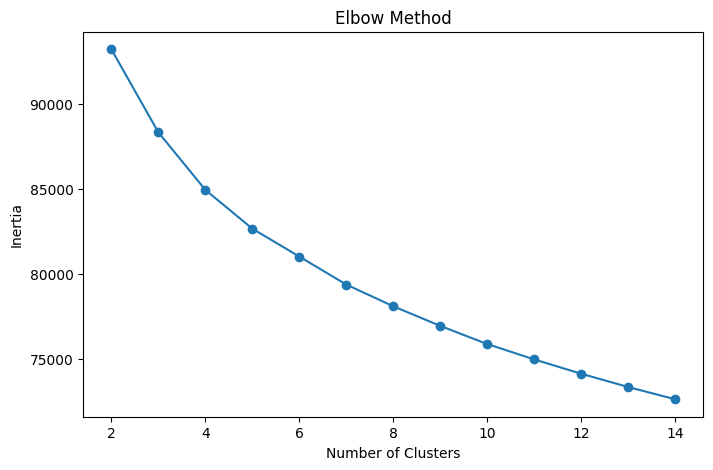

In [7]:
plt.figure(figsize=(8,5))

plt.plot(
    range(2,15),
    inertia_avg,
    marker='o'
)

plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.title("Elbow Method")

plt.show()

In [8]:
scores_avg = []

for k in range(2, 15):
    km = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=20
    )
    
    labels = km.fit_predict(X_avg_scaled)
    
    score = silhouette_score(X_avg_scaled, labels)
    scores_avg.append(score)

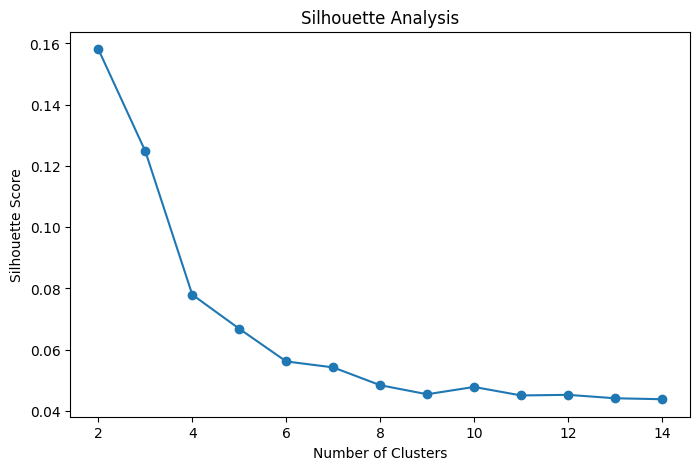

In [9]:
plt.figure(figsize=(8,5))

plt.plot(
    range(2,15),
    scores_avg,
    marker='o'
)

plt.xlabel("Number of Clusters")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Analysis")

plt.show()

In [10]:
x=5
kmeans = KMeans(
    n_clusters=x,
    random_state=42,
    n_init=20
)

labels = kmeans.fit_predict(X_avg_scaled)

df_avg[f"cluster_{x}"] = labels

In [11]:
cluster_avg_summary = (df_avg.drop(columns=fl.metadata_features).groupby(f"cluster_{x}").mean())

with pd.option_context('display.max_rows', None, 'display.max_colwidth', None):
    display(cluster_avg_summary.transpose())

cluster_5,0,1,2,3,4
number_of_seasons,2.159633,2.046322,2.306667,2.402116,2.097852
appearances,27.138226,27.188919,29.318222,28.475309,28.572395
matchesstarted,21.753211,19.856494,23.679556,22.287478,20.936356
minutesplayed,1917.977370,1762.904178,2091.881333,1943.140212,1828.403341
dispossessed_per_touch_zscore,-0.646894,0.146936,-0.455636,0.377358,1.026405
groundduelswon_per90_zscore,-0.112833,0.124165,-0.151985,0.274387,0.198216
keypasses_per90_zscore,-0.815818,-0.368193,0.502510,1.430444,0.220956
expectedgoals_per90_zscore,-0.591986,-0.113738,-0.217879,0.939525,0.564236
accuratecrossespercentage_zscore,-0.085996,-0.192658,0.278796,0.206809,-0.134956
fouls_per90_zscore,0.238664,0.419549,-0.297216,-0.490063,-0.139744


In [12]:
pca = PCA(n_components=2)

X_avg_pca = pca.fit_transform(X_avg_scaled)

df_avg["PC1"] = X_avg_pca[:,0]
df_avg["PC2"] = X_avg_pca[:,1]

fig = px.scatter(
    df_avg,
    x="PC1",
    y="PC2",
    color=f"cluster_{x}",
    hover_name='player',         
    hover_data=['team','appearances','minutesplayed'], 
    title=f"Midfielders Avg Clusters (K={x})",
    width=1000,
    height=700
)

fig.show()

In [13]:
df_avg[f"cluster_{x}"].value_counts()

cluster_5
0    545
4    419
2    375
1    367
3    189
Name: count, dtype: int64

In [14]:
pca = PCA()

X_pca = pca.fit_transform(X_avg_scaled)

cum_var = np.cumsum(pca.explained_variance_ratio_)

In [15]:
var_df = pd.DataFrame({
    "Components": range(1, len(cum_var)+1),
    "Cumulative Variance": cum_var
})

px.line(
    var_df,
    x="Components",
    y="Cumulative Variance",
    title="PCA Explained Variance"
).show()

In [16]:
pca_sizes = range(16,24)

pca_datasets = {}

for n in pca_sizes:
    pca = PCA(n_components=n, random_state=42)
    pca_datasets[n] = pca.fit_transform(X_avg_scaled)

In [17]:
results = []

for n_comp, X_pca in pca_datasets.items():

    for k in range(4, 11):

        kmeans = KMeans(
            n_clusters=k,
            random_state=42,
            n_init=20
        )

        labels = kmeans.fit_predict(X_pca)

        sil = silhouette_score(X_pca, labels)

        results.append(
            {
                "n_components": n_comp,
                "k": k,
                "silhouette": sil
            }
        )

In [18]:
results_df = pd.DataFrame(results)

results_df.sort_values(
    "silhouette",
    ascending=False
).head(20)

,n_components,k,silhouette
0,16,4,0.112362
7,17,4,0.109432
28,20,4,0.106676
14,18,4,0.106670
21,19,4,0.105125
35,21,4,0.100922
49,23,4,0.099212
42,22,4,0.098894
1,16,5,0.094894
8,17,5,0.092279


In [19]:
x=16
pca = PCA(n_components=x)
X_pca = pca.fit_transform(X_avg_scaled)

loadings = pd.DataFrame(
    pca.components_.T,
    index=X_avg.columns.tolist(),
    columns=[f"PC{i+1}" for i in range(x)]
)

loadings

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,PC11,PC12,PC13,PC14,PC15,PC16
dispossessed_per_touch_zscore,0.169830,-0.171733,0.163743,0.022040,-0.157694,-0.068387,0.019922,0.046317,-0.032094,-0.090293,0.120534,-0.096582,0.041422,0.082208,0.011740,0.000331
groundduelswon_per90_zscore,0.043011,0.004854,0.387810,0.185430,-0.201164,0.053468,0.158079,-0.078871,0.212968,0.043981,-0.038723,0.009305,-0.100914,-0.087361,0.034015,-0.003991
keypasses_per90_zscore,0.186232,0.214728,0.042734,-0.106725,0.100026,-0.019790,0.014685,-0.041570,-0.023422,0.095210,0.077868,-0.206251,-0.041049,-0.028901,0.025478,0.009039
expectedgoals_per90_zscore,0.202683,-0.033718,-0.052378,0.121126,0.022224,0.129545,-0.213222,-0.104639,0.000483,0.066970,-0.060598,0.123089,0.026480,-0.079439,0.001761,-0.028525
accuratecrossespercentage_zscore,0.011986,0.142871,-0.001760,-0.071940,0.040906,-0.072330,0.035273,-0.040871,0.021313,0.149895,0.012222,-0.309325,-0.039642,-0.169601,-0.354785,-0.454532
fouls_per90_zscore,-0.064034,-0.114467,0.217731,0.202513,0.051336,-0.061010,-0.070976,0.161815,-0.137777,-0.024381,-0.133669,-0.213250,-0.141529,-0.054295,-0.057386,-0.137073
successfuldribbles_per90_zscore,0.165549,-0.010054,0.216529,0.002437,-0.189519,0.022810,0.112165,-0.071730,0.092918,-0.161595,0.059739,-0.007091,0.139399,0.192087,-0.034032,0.015332
bigchancesmissed_per90_zscore,0.176833,-0.123662,-0.014732,0.065180,0.071777,0.171748,-0.167998,-0.172984,-0.039437,0.064024,-0.043309,0.113841,0.079173,-0.091091,0.032482,-0.069538
leftfootgoals_per90_zscore,0.154243,0.036297,-0.076299,0.084445,0.012070,-0.032264,-0.005413,0.069794,0.091357,-0.061103,-0.265973,-0.086038,0.259379,-0.300743,-0.057553,0.477669
ballrecovery_per90_zscore,-0.104764,0.179739,0.211325,0.156897,-0.043994,0.002743,0.009423,-0.029335,-0.189488,-0.004186,0.136676,0.100746,0.092998,0.094052,-0.024687,0.035702


In [20]:
for pc in loadings.columns:
    print(f"\n{pc}")
    print(loadings[pc].abs().sort_values(ascending=False).head(10))


PC1
final_third_pass_pct_zscore         0.234535
shotsontarget_per90_zscore          0.232911
goals_per90_zscore                  0.215560
expectedgoals_per90_zscore          0.202683
blockedshots_per90_zscore           0.194578
bigchancescreated_per90_zscore      0.191266
possession_lost_per_touch_zscore    0.190348
clearances_per90_zscore             0.186412
keypasses_per90_zscore              0.186232
interceptions_per90_zscore          0.183522
Name: PC1, dtype: float64

PC2
touches_per90_zscore                     0.321869
accuratefinalthirdpasses_per90_zscore    0.290854
accuratelongballs_per90_zscore           0.290591
inside_box_shot_pct_zscore               0.227476
aeriallost_per90_zscore                  0.226643
keypasses_per90_zscore                   0.214728
expectedassists_per90_zscore             0.184788
accuratecrosses_per90_zscore             0.184176
ballrecovery_per90_zscore                0.179739
duellost_per90_zscore                    0.179239
Name: PC2, dty

In [21]:
pca_df = pd.DataFrame(
    X_pca,
    columns=[f"PC{i+1}" for i in range(x)]
)

In [22]:
results=[]
for k in range(2, 11):
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=20
    )

    labels = kmeans.fit_predict(X_pca)

    results.append({
        "k": k,
        "silhouette": silhouette_score(X_pca, labels),
        "inertia": kmeans.inertia_
    })

df_results = pd.DataFrame(results)

In [23]:
px.line(
    df_results,
    x="k",
    y="inertia",
    markers=True,
    title="Elbow Method"
).show()

px.line(
    df_results,
    x="k",
    y="silhouette",
    markers=True,
    title="Silhouette Score"
).show()

In [24]:
cluster=4

kmeans_pca = KMeans(n_clusters=cluster, random_state=42, n_init=20)
df_avg[f'pca_cluster_{cluster}'] = kmeans_pca.fit_predict(X_pca)

cluster_summary = (df_avg.drop(columns=fl.metadata_features+['cluster_5','PC1','PC2',]).groupby(f"pca_cluster_{cluster}").mean())

with pd.option_context('display.max_rows', None, 'display.max_colwidth', None):
    display(cluster_summary.transpose())

pca_cluster_4,0,1,2,3
number_of_seasons,2.332569,2.068140,2.329457,2.104863
appearances,29.259939,28.177716,28.314599,26.981256
matchesstarted,23.759939,20.236648,22.102067,21.211499
minutesplayed,2095.397936,1780.681400,1925.777132,1873.464286
dispossessed_per_touch_zscore,-0.461348,0.788114,0.580331,-0.523760
groundduelswon_per90_zscore,-0.125597,0.137415,0.317337,-0.060391
keypasses_per90_zscore,0.416241,-0.020140,1.250831,-0.792753
expectedgoals_per90_zscore,-0.242527,0.350308,0.926174,-0.540307
accuratecrossespercentage_zscore,0.281043,-0.194735,0.169981,-0.138500
fouls_per90_zscore,-0.244951,0.100451,-0.481887,0.300907


In [25]:
df_avg["PC1"] = X_pca[:,0]
df_avg["PC2"] = X_pca[:,1]

fig = px.scatter(
    df_avg,
    x="PC1",
    y="PC2",
    color=f"pca_cluster_4",
    hover_name='player',         
    hover_data=['team','minutesplayed','number_of_seasons'], 
    title=f"Midfielders Clusters (K={cluster})",
    width=1000,
    height=700
)

fig.show()

In [26]:
y=cluster
distances = cdist(X_pca, kmeans_pca.cluster_centers_)

for cluster in range(cluster):

    members = df_avg[df_avg[f"pca_cluster_4"] == cluster]

    member_idx = members.index

    d = distances[member_idx, cluster]

    closest_idx = member_idx[np.argsort(d)[:20]]
    
    print('cluster number-' ,cluster)

    print(df_avg.loc[closest_idx, ["player","team"]])

cluster number- 0
                   player                    team
338            Theo Valls        Grenoble Foot 38
938           Josh Eccles           Coventry City
85              Moi Gómez                 Osasuna
1054         Tyler Morton      Olympique Lyonnais
1051          Semih Şahin    1. FC Kaiserslautern
728         Alberto Reina             Real Oviedo
463      Pervis Estupiñán                AC Milan
493   Santiago Colombatto             Real Oviedo
742         Hwang In-beom               Feyenoord
855        Giuseppe Leone             Juve Stabia
203      Manolis Saliakas            FC St. Pauli
763        Gianluca Busio                 Venezia
1513        Mouhamed Diop                  Troyes
1291          Yasin Ayari  Brighton & Hove Albion
1274      Tanner Tessmann      Olympique Lyonnais
233                 Bicho        Cultural Leonesa
756   Alexis Mac Allister            Liverpool FC
624           Declan Rice                 Arsenal
1740    Arthur Avom Ebong       

In [27]:
cluster_mapping = {
    0: "Deep Lying Playmaker",
    1: "Press Runner",
    2: "Advanced Playmaker",
    3: "Defensive Midfielder"
}

df_avg['cluster']=df_avg['pca_cluster_4']
df_avg=df_avg.drop(columns=['cluster_5','pca_cluster_4'])
df_avg['cluster_name']=df_avg["cluster"].map(cluster_mapping)

In [28]:
df_ewma=pd.read_csv('../../../data/processed/major_leagues/Midfielders/EWMA_Major_Midfielders.csv')

In [29]:
import joblib

joblib.dump(scaler, "../../../models/major_leagues/Midfielders/scaler.pkl")
joblib.dump(pca, "../../../models/major_leagues/Midfielders/pca.pkl")
joblib.dump(kmeans_pca, "../../../models/major_leagues/Midfielders/kmeans.pkl")

['../../../models/major_leagues/Midfielders/kmeans.pkl']

In [30]:
X_pca_avg = pca.transform(X_avg_scaled)
pca_cols = [f'PC{i+1}' for i in range(16)]
df_coords_avg = pd.DataFrame(X_pca_avg, columns=pca_cols, index=df_avg.index)

df_avg_clustered = pd.concat([df_avg, df_coords_avg], axis=1)
df_avg_clustered['cluster'] = kmeans_pca.labels_
df_avg_clustered['cluster_name'] = df_avg_clustered['cluster'].map(cluster_mapping)

df_avg_clustered.to_csv('../../../data/processed/major_leagues/Midfielders/Avg_Major_Midfielders_Clustered.csv', index=False)

In [31]:
X_ewma=df_ewma.drop(columns=fl.metadata_features + ['minutesplayed','number_of_seasons','appearances','matchesstarted'])

X_scaled_ewma = scaler.transform(X_ewma)
X_pca_ewma = pca.transform(X_scaled_ewma)

pca_cols = [f'PC{i+1}' for i in range(16)]
df_coords_ewma = pd.DataFrame(X_pca_ewma, columns=pca_cols, index=df_ewma.index)

df_ewma_clustered = pd.concat([df_ewma, df_coords_ewma], axis=1)

df_ewma_clustered['cluster']=df_avg['cluster']
df_ewma_clustered['cluster_name']=df_avg['cluster_name']

df_ewma_clustered.to_csv('../../../data/processed/major_leagues/Midfielders/EWMA_Major_Midfielders_Clustered.csv', index=False)